# Exploratory Data Analysis

**Research question:** Did the 2025 tariff shock produce asymmetric liquidity responses across sectors, and can option market microstructure signal which sectors the market treated as structurally damaged versus temporarily disrupted?

**Key event dates:**
- Apr 2 2025 — Liberation Day (tariff announcement)
- Apr 9 2025 — Escalation + 90-day pause
- May 12 2025 — US-China truce, recovery begins

**Analysis notes:**
- All cross-sector charts use Mar 24 2025 as the common start date (all tickers have data from then).
- Spread analysis filters out illiquid contracts (bid = 0) to avoid quoting artefacts.
- ATM contracts (within 3% of spot) are used for like-for-like comparisons.
- IV and Greeks are unavailable (plan limitation) — analysis uses bid-ask spread and relative spread as liquidity proxies.

**Figures:**
- Fig 1: Indexed stock prices
- Fig 2: Realised volatility
- Fig 3: ATM relative spread over time (core finding)
- Fig 4: Spread distribution by phase (box plots)
- Fig 5: Event study centred on Liberation Day
- Fig 6: Open interest over time
- Fig 7: Call vs put spread during shock (Phase 2)
- Fig 8: Recovery ratio vs Phase 1 baseline

To save a figure, uncomment the `save(fig, ...)` line at the bottom of its cell.

In [14]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path

# Path().resolve() returns the directory the notebook kernel was started from.
# If you open Jupyter from the project root, use .resolve() directly.
# If you open it from the notebooks/ folder, use .resolve().parent.

PROJECT_ROOT = Path().resolve().parent   # adjust if needed
COMBINED_CSV = PROJECT_ROOT / "data" / "combined" / "combined_all.csv"
FIG_DIR      = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Global Styling
# Consistent colour for each ticker across every chart
COLORS = {
    "AAPL": "#2196F3",   # blue
    "NVDA": "#4CAF50",   # green
    "AMZN": "#FF9800",   # orange
    "PG":   "#E53935",   # red
    "CAT":  "#9C27B0",   # purple
}
TICKERS = list(COLORS.keys())

# Key event dates
EVENTS = {
    "Liberation Day\n(Apr 2)":       pd.Timestamp("2025-04-02"),
    "Escalation + Pause\n(Apr 9)":   pd.Timestamp("2025-04-09"),
    "US-China Truce\n(May 12)":      pd.Timestamp("2025-05-12"),
}
EVENT_COLORS = ["#E53935", "#FB8C00", "#43A047"]

# Cross-sector analysis starts here (all tickers have data from this date)
COMMON_START = pd.Timestamp("2025-03-24")

plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.size":         10,
})

# Stagger Apr 2 and Apr 9 labels so they don't overlap (only 7 days apart).
# y values are axes fractions (0 = bottom, 1 = top) via get_xaxis_transform().
_EVENT_Y = [0.97, 0.80, 0.97]

def add_event_lines(ax):
    """
    Draw a vertical dashed line for each key event date and add a text label
    at the top of the axis. Called on every time-series chart so the same
    three events are consistently annotated across all figures.

    Uses get_xaxis_transform() so x is in data coordinates and y is an axes
    fraction (0–1), making placement robust regardless of y-axis scale or range.
    Apr 2 and Apr 9 are staggered vertically to prevent label overlap.
    """
    trans = ax.get_xaxis_transform()
    for i, ((label, dt), color) in enumerate(zip(EVENTS.items(), EVENT_COLORS)):
        ax.axvline(dt, color=color, linestyle="--", linewidth=1.2, alpha=0.8, zorder=3)
        ax.text(
            dt, _EVENT_Y[i], label,
            transform=trans,
            color=color, fontsize=7, ha="center", va="top",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
        )


def save(fig, name):
    """Save figure to outputs/figures/ and print confirmation."""
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"  Saved: {name}")


In [2]:
df = pd.read_csv(
    COMBINED_CSV,
    parse_dates=["collection_date", "expiration"],
    dtype={"ticker": str, "side": str, "moneyness_cat": str},
)
df["is_illiquid"] = df["is_illiquid"].astype(bool)
liquid = df[~df["is_illiquid"]].copy()
atm    = liquid[liquid["moneyness_cat"] == "ATM"].copy()
cross  = atm[atm["collection_date"] >= COMMON_START].copy()

---
## Figure 1 — Indexed Stock Prices

Shows the raw equity price movement for each ticker across the study period, normalised to 100%.
Eg. A drop to 80 means a 20% drawdown regardless of the stock's starting price. 

What we observe from the figure:
- Dip observed for all sectors right after the Tariff announcement
- Overtime, all sectors recovered to go above 100 except for PG which remained below 100 for most of the year.


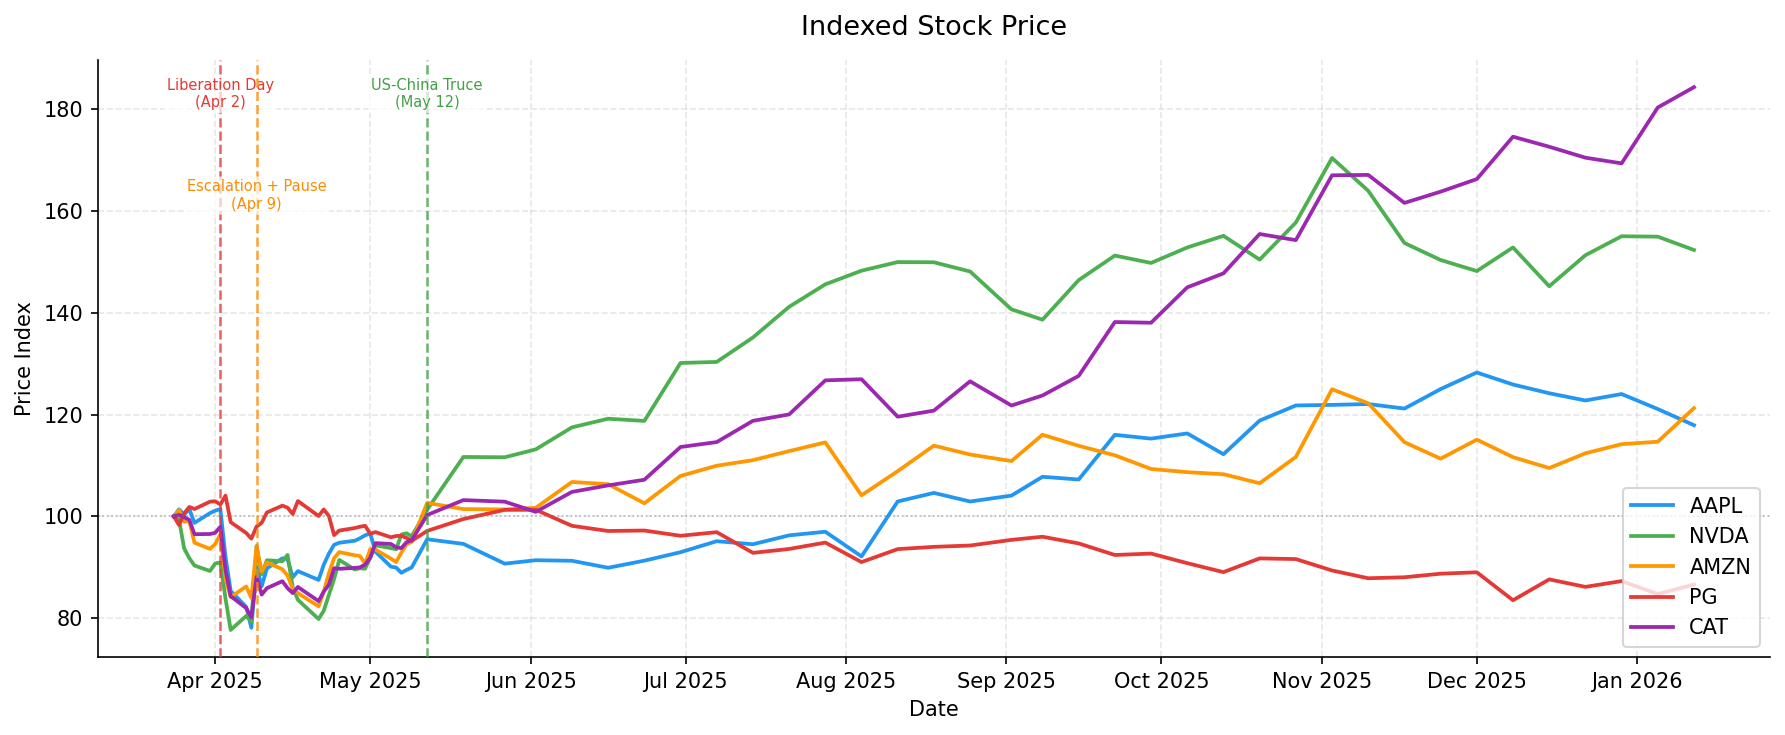

In [16]:
price_ts = (
    cross.groupby(["collection_date", "ticker"])["underlyingPrice"]
    .median()
    .reset_index()
)

# Normalise to 100 at the common start date so all tickers are on the same scale.
price_norm = price_ts.copy()
for ticker in TICKERS:
    mask  = price_norm["ticker"] == ticker
    base  = price_norm.loc[mask, "underlyingPrice"].iloc[0]
    price_norm.loc[mask, "price_idx"] = (
        price_norm.loc[mask, "underlyingPrice"] / base * 100
    )

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    data = price_norm[price_norm["ticker"] == ticker]
    ax.plot(data["collection_date"], data["price_idx"],
            color=COLORS[ticker], label=ticker, linewidth=1.8)

add_event_lines(ax)
ax.axhline(100, color="grey", linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_title("Indexed Stock Price", fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price Index")
ax.legend(loc="lower right", framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()

# save(fig, "fig1_prices.png")
plt.show()

## Figure 2: Realised Volatility

Realised Volatility (RV) is the rolling 20-day annualised standard deviation of log returns.
RV measures the actual magnitude of price fluctuations an asset experienced over a specific period, expressed as an annualised standard deviation of its returns

Interpretation of results:
- High RV can be a market signal for increased uncertainty or stress in the market

What we observe from the figure:
- A significant spike in RV around Liberation Day (stressful period to be in the market)
- The spike confirms that the tariff shock was a genuine volatility event.

Note: AAPL has full coverage; other tickers only have RV from ~Apr 22 onwards (the 20-day window needs 20 prior trading days).

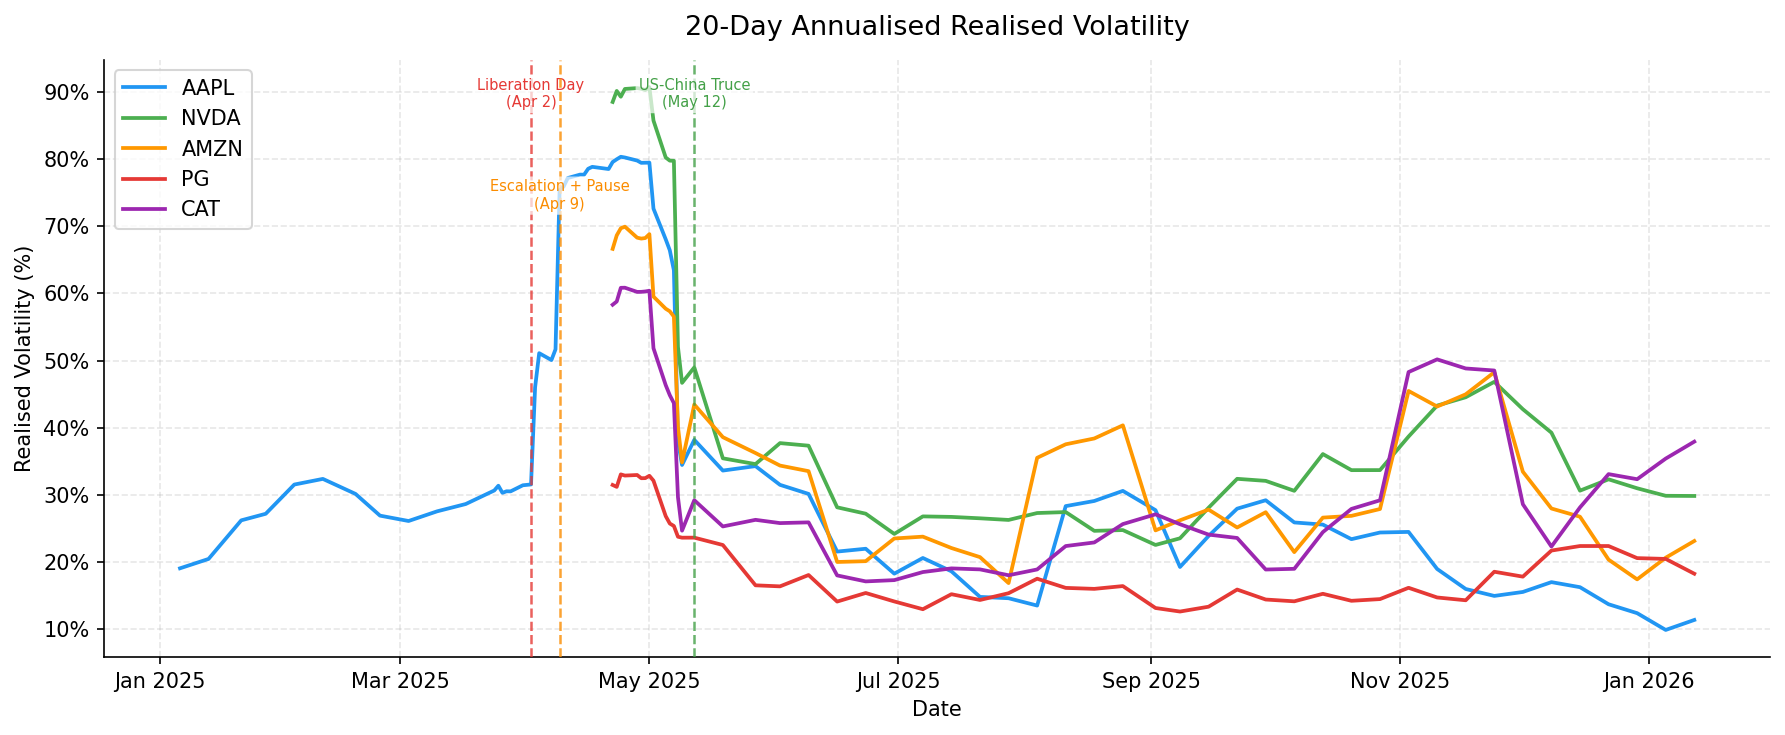

In [20]:
rv_ts = (
    df.dropna(subset=["realised_vol"])
    .groupby(["collection_date", "ticker"])["realised_vol"]
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    data = rv_ts[rv_ts["ticker"] == ticker]
    ax.plot(data["collection_date"], data["realised_vol"] * 100,
            color=COLORS[ticker], label=ticker, linewidth=1.8)

add_event_lines(ax)
ax.set_title("20-Day Annualised Realised Volatility", fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Realised Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(loc="upper left", framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()

# save(fig, "fig2_realised_vol.png")
plt.show()

## Figure 3: ATM Relative Spread Over Time

$$\text{relative spread} = \frac{\text{spread}}{\text{mid-price}}$$

Relative spread measures the cost of trading as a fraction of the option's price (Eg. a relative spread of 0.10 means you pay 10% of the option's value to enter and exit a position)

ATM contracts are used because they are the most actively traded and give the cleanest liquidity signal, free of deep-OTM illiquidity artefacts.

Interpretation of results:
- A lower relative spread % is an indicator of high liquidity and high trading volume

What we observe from the figure:
- Apr 2 - Apr 9: A spike in relative spread (expected due to the tariff shocks)
- The height of the spike varies by sector (asymmetric response)
- The speed of recovery in Phase 3 also differs (structural vs temporary damage)

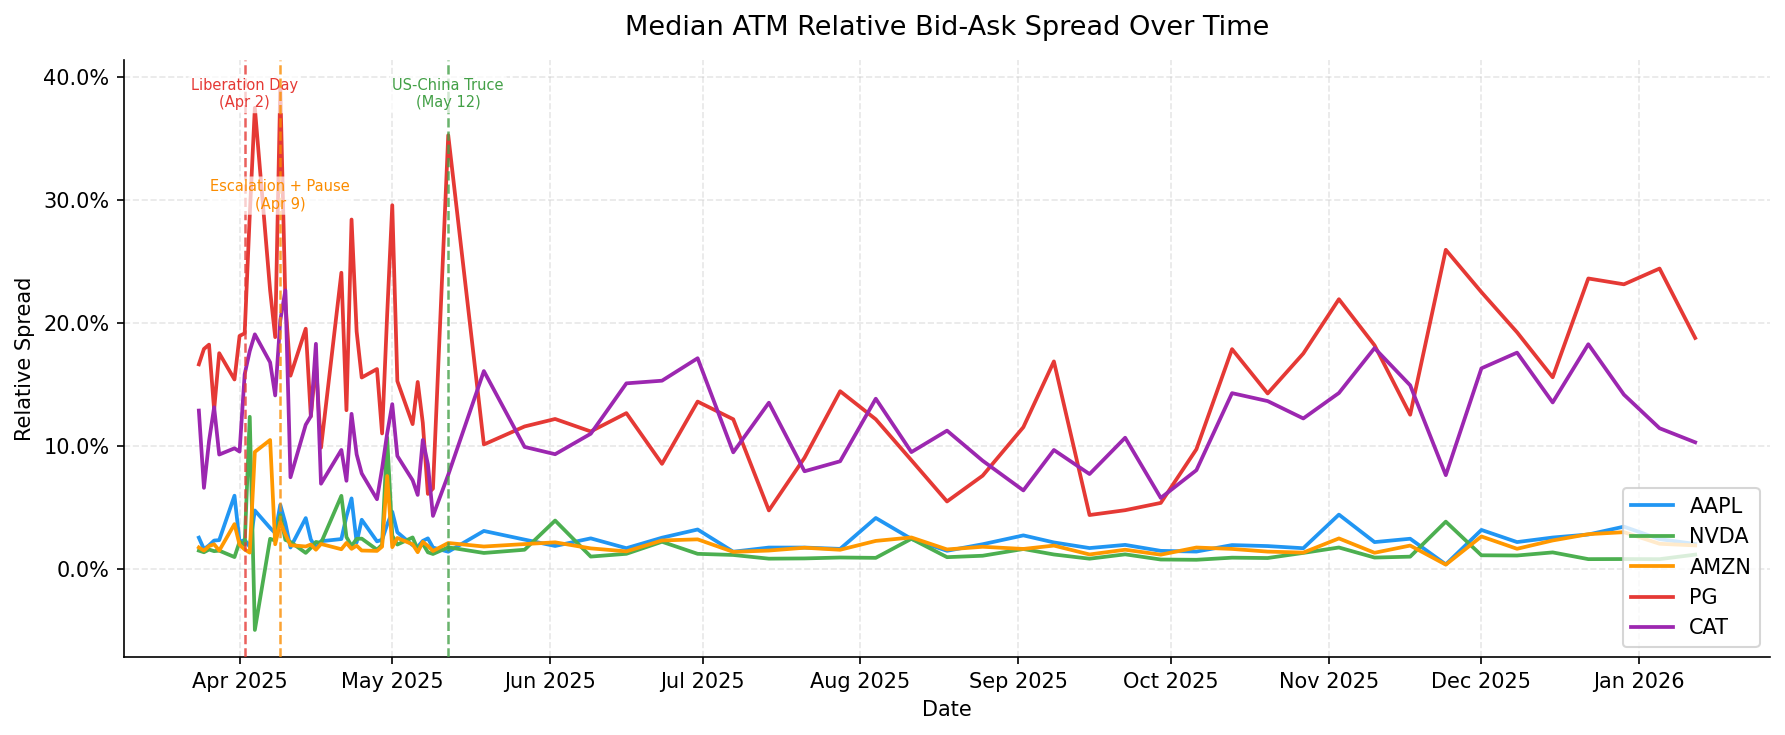

In [23]:
spread_ts = (
    cross.groupby(["collection_date", "ticker"])["relative_spread"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    data = spread_ts[spread_ts["ticker"] == ticker]
    ax.plot(data["collection_date"], data["relative_spread"],
            color=COLORS[ticker], label=ticker, linewidth=1.8)

add_event_lines(ax)
ax.set_title("Median ATM Relative Bid-Ask Spread Over Time", fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Relative Spread")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(loc="lower right", framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()

# save(fig, "fig3_spread_timeline.png")
plt.show()

## Figure 4: Spread Distribution by Phase

We use box plots to show the full distribution of relative spreads in each phase, not just the median. 

Interpretation of results:
- A tall box represents large fluctuations in transaction cost. The market is unstable and illiquid.
- A short box represents little fluctuation in transaction costs. the market is consistent and liquid.

What we observe from the figure:
- Across all sectors, the spread remains consistent throughout all phases.
- AAPL, NVDA and AMZN have a very little fluctuations in spread throughout all phases.
- PG and CAT have the largest fluctuations in spread througout all phases.

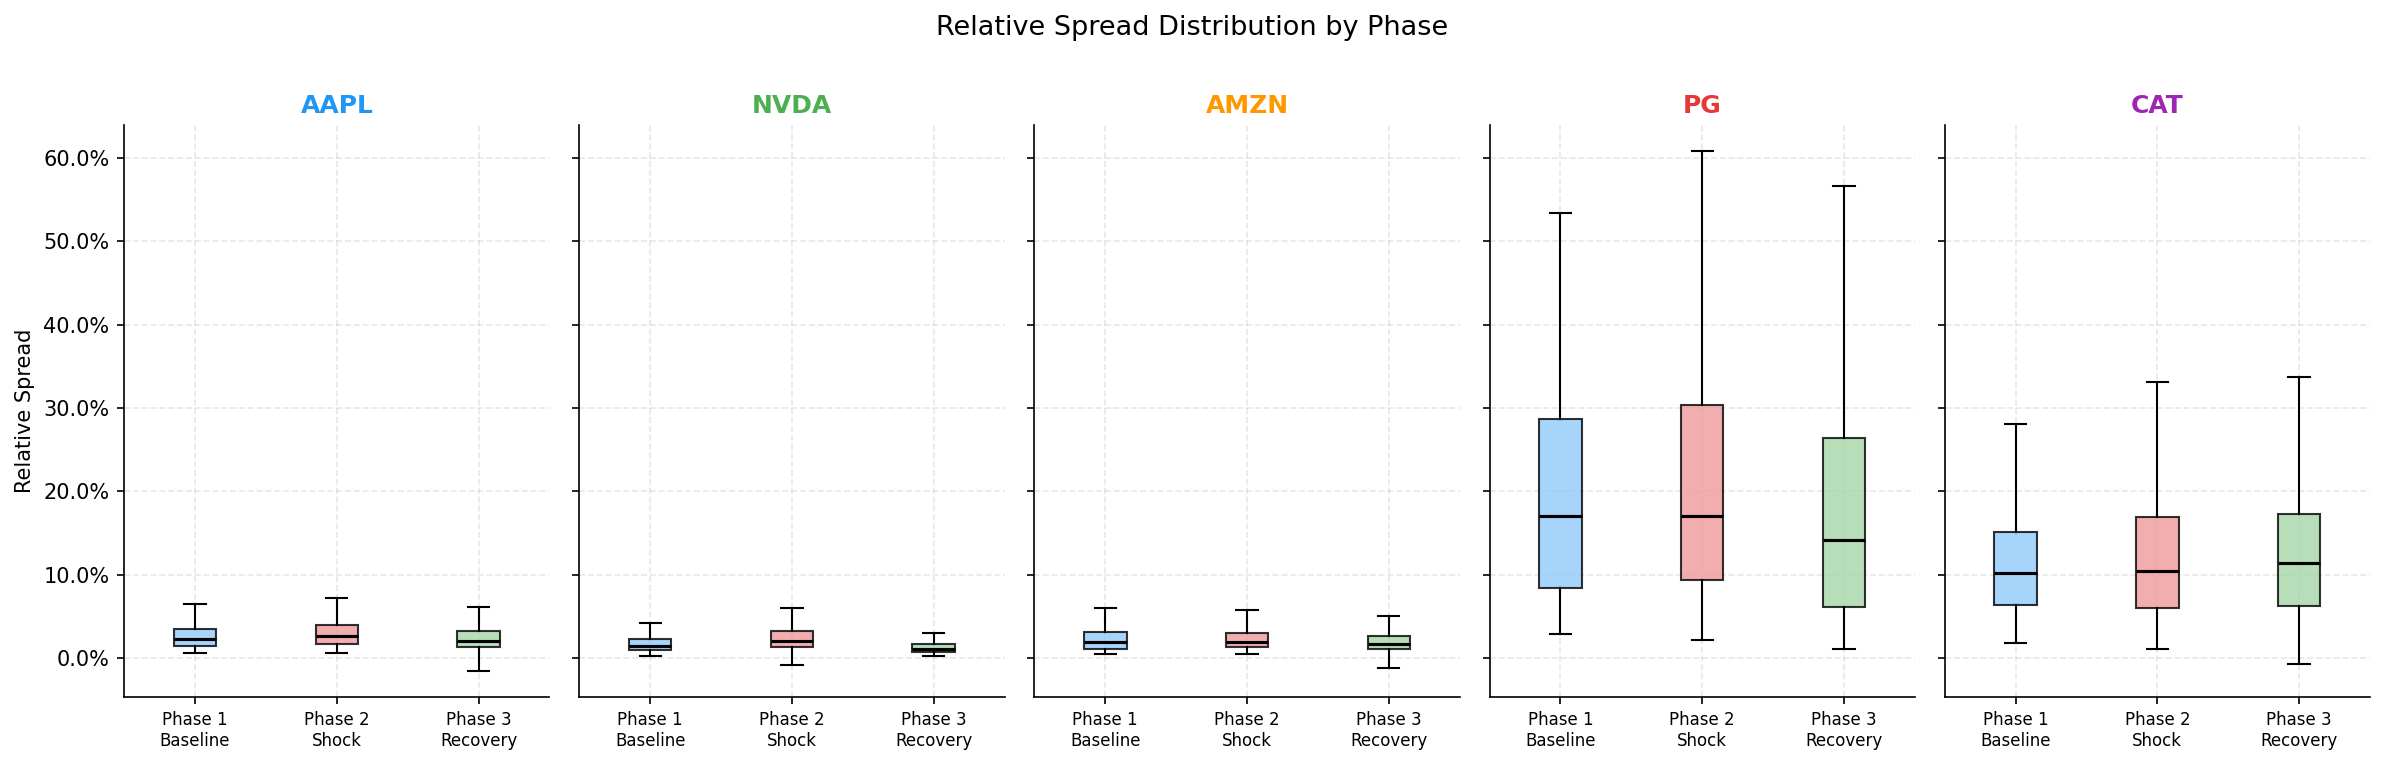

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)

phase_labels = {1: "Phase 1\nBaseline", 2: "Phase 2\nShock", 3: "Phase 3\nRecovery"}
phase_colors = {1: "#90CAF9", 2: "#EF9A9A", 3: "#A5D6A7"}

for ax, ticker in zip(axes, TICKERS):
    data = cross[cross["ticker"] == ticker]
    phase_data = [
        data.loc[data["phase"] == p, "relative_spread"].dropna().values
        for p in [1, 2, 3]
    ]
    bp = ax.boxplot(
        phase_data,
        tick_labels=[phase_labels[p] for p in [1, 2, 3]],
        patch_artist=True,
        showfliers=False,    # hide extreme outliers to keep the chart readable
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
    )
    for patch, p in zip(bp["boxes"], [1, 2, 3]):
        patch.set_facecolor(phase_colors[p])
        patch.set_alpha(0.8)

    ax.set_title(ticker, color=COLORS[ticker], fontweight="bold", fontsize=12)
    ax.tick_params(axis="x", labelsize=8)
    if ax == axes[0]:
        ax.set_ylabel("Relative Spread")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

fig.suptitle("Relative Spread Distribution by Phase",
             fontsize=13, y=1.01)
fig.tight_layout()

# save(fig, "fig4_spread_by_phase.png")
plt.show()

## Figure 5: Relative Spread Centred on Liberation Day

An event study aligns all observations on a common time axis: the number of days before or after the event (Liberation Day = day 0). 

This lets you see the typical pattern of spread behaviour across tickers without phase boundaries obscuring the signal.

Interpretation of Results
- a


Observations from figure:
- A sharp jump at day 0 (Liberation Day announcement)
- A second jump or plateau around day +7 (Apr 9 escalation)
- Different recovery slopes by ticker after day +7

Generating Figure 5: event study...


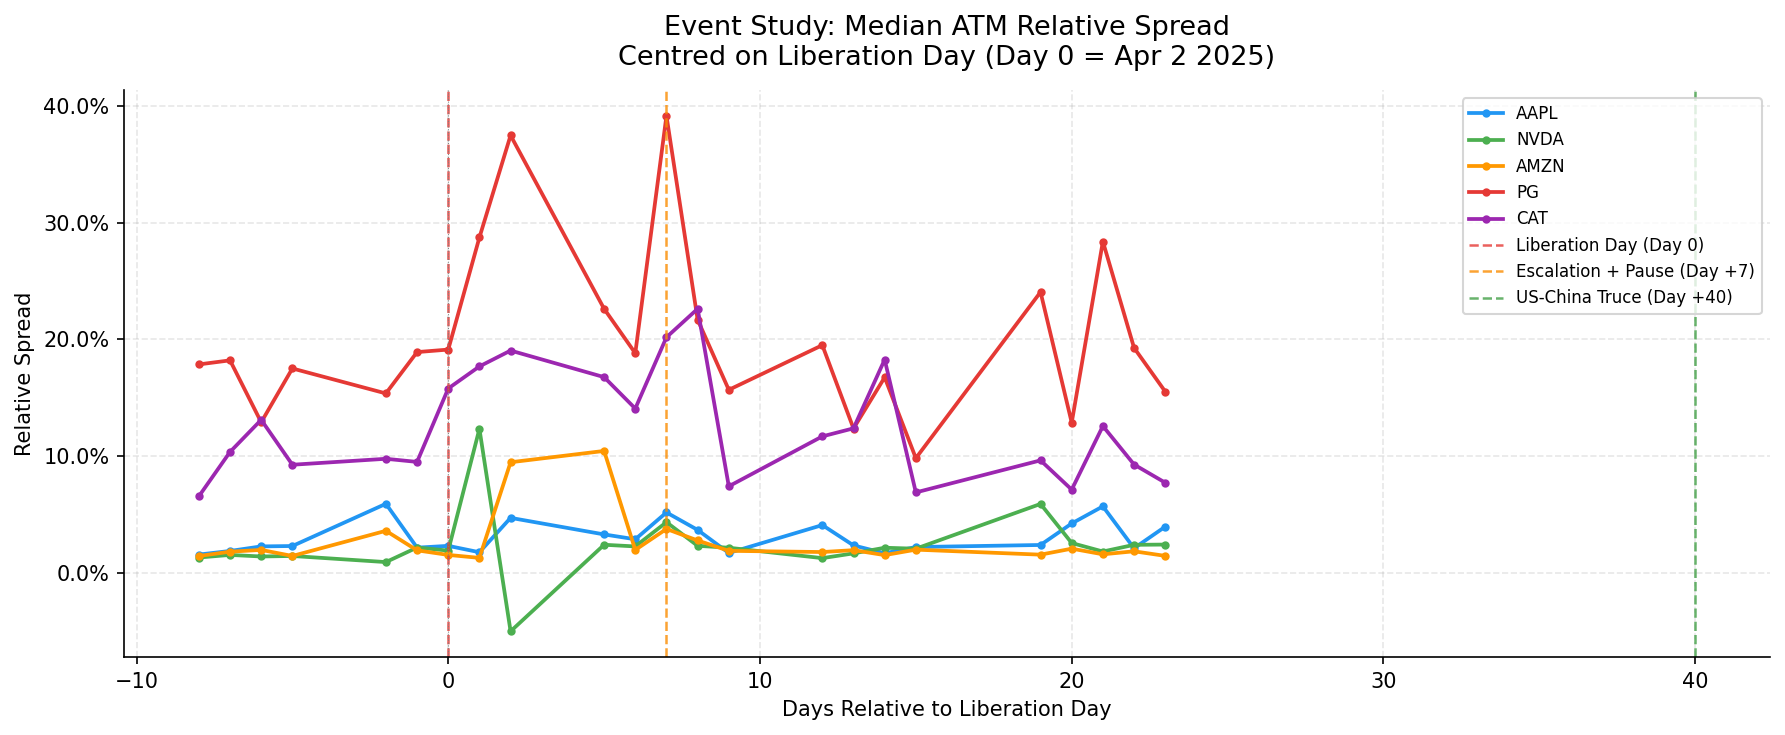

In [27]:
print("Generating Figure 5: event study...")

event_window = cross[
    (cross["days_from_apr2"] >= -8) &
    (cross["days_from_apr2"] <= 25)
].copy()

event_ts = (
    event_window.groupby(["days_from_apr2", "ticker"])["relative_spread"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    data = event_ts[event_ts["ticker"] == ticker]
    ax.plot(data["days_from_apr2"], data["relative_spread"],
            color=COLORS[ticker], label=ticker, linewidth=1.8, marker="o",
            markersize=3)

ax.axvline(0,  color=EVENT_COLORS[0], linestyle="--", linewidth=1.2,
           label="Liberation Day (Day 0)", alpha=0.8)
ax.axvline(7,  color=EVENT_COLORS[1], linestyle="--", linewidth=1.2,
           label="Escalation + Pause (Day +7)", alpha=0.8)
ax.axvline(40, color=EVENT_COLORS[2], linestyle="--", linewidth=1.2,
           label="US-China Truce (Day +40)", alpha=0.8)

ax.set_title("Event Study: Median ATM Relative Spread\nCentred on Liberation Day (Day 0 = Apr 2 2025)",
             fontsize=13, pad=12)
ax.set_xlabel("Days Relative to Liberation Day")
ax.set_ylabel("Relative Spread")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(loc="upper right", framealpha=0.8, fontsize=8)
ax.axvline(0, color="grey", linewidth=0.5, linestyle=":")
fig.tight_layout()

# save(fig, "fig5_event_study.png")
plt.show()

## Figure 6 — Open Interest Over Time

Open interest (OI) represents the total number of outstanding contracts. 

Interpretation of results:
- Rising OI means more new positions are being opened than they are being closed.
- Falling OI means more positions are being closed than they are being opened.

Observation from figure:
- Apr 2 - Apr 9: Sharp Dip in OI (Traders close out positions because the risk becomes too unpredictable.)
- Right after Apr 9: Sharp increase in OI
- After May 12: Long-term upward trend in OI. (signals that confidence returned to the market, and traders were willing to hold positions / open new positions)
- OI for PG and CAT are consistently low throughout all phases

Generating Figure 6: open interest...


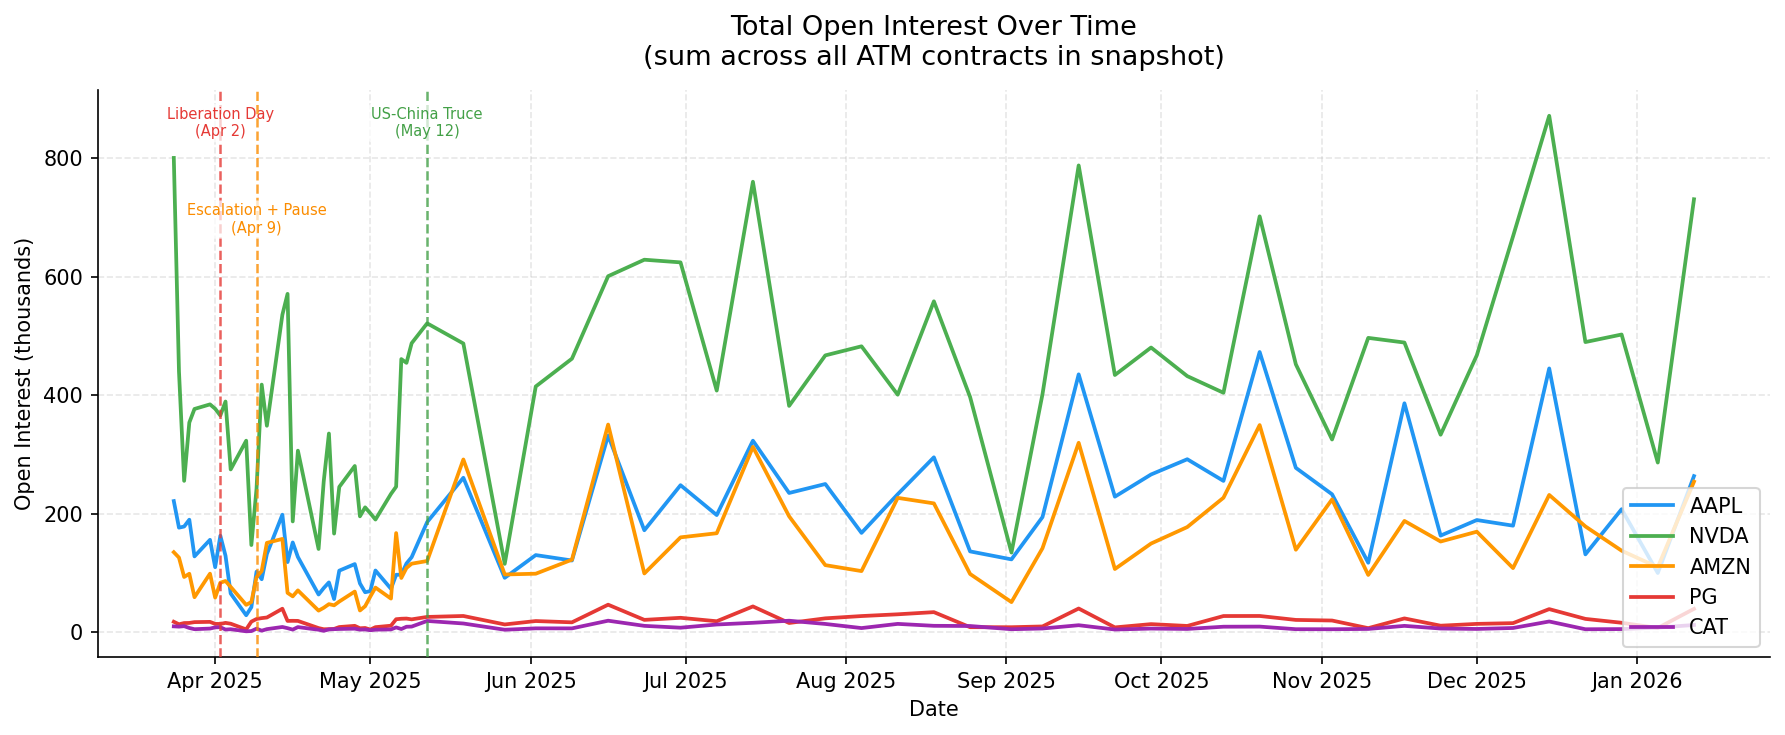

In [ ]:
oi_ts = (
    cross.groupby(["collection_date", "ticker"])["openInterest"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    data = oi_ts[oi_ts["ticker"] == ticker]
    ax.plot(data["collection_date"], data["openInterest"] / 1_000,
            color=COLORS[ticker], label=ticker, linewidth=1.8)

add_event_lines(ax)
ax.set_title("Total Open Interest Over Time\n(sum across all ATM contracts in snapshot)",
             fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Open Interest (thousands)")
ax.legend(loc="lower right", framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()

# save(fig, "fig6_open_interest.png")
plt.show()

## Figure 7: Calls vs Puts Relative Spread During Phase 2

This figure explores put-call parity, which states that call and put spreads should be roughly equal for the same strike and expiry.

During a high volatility event, put spreads typically widen more than call spreads because demand for downside protection surges, overwhelming market makers' willingness to quote tight markets. 

A widening gap between put and call spreads is a direct measure of how asymmetric the fear was.


Observation from figure:
- For AAPL, CAT and AMZN: 
- For NVDA: call spreads widened more than put spreads
- For PG: put spreads widened more than call spreads

Generating Figure 7: call vs put spread...


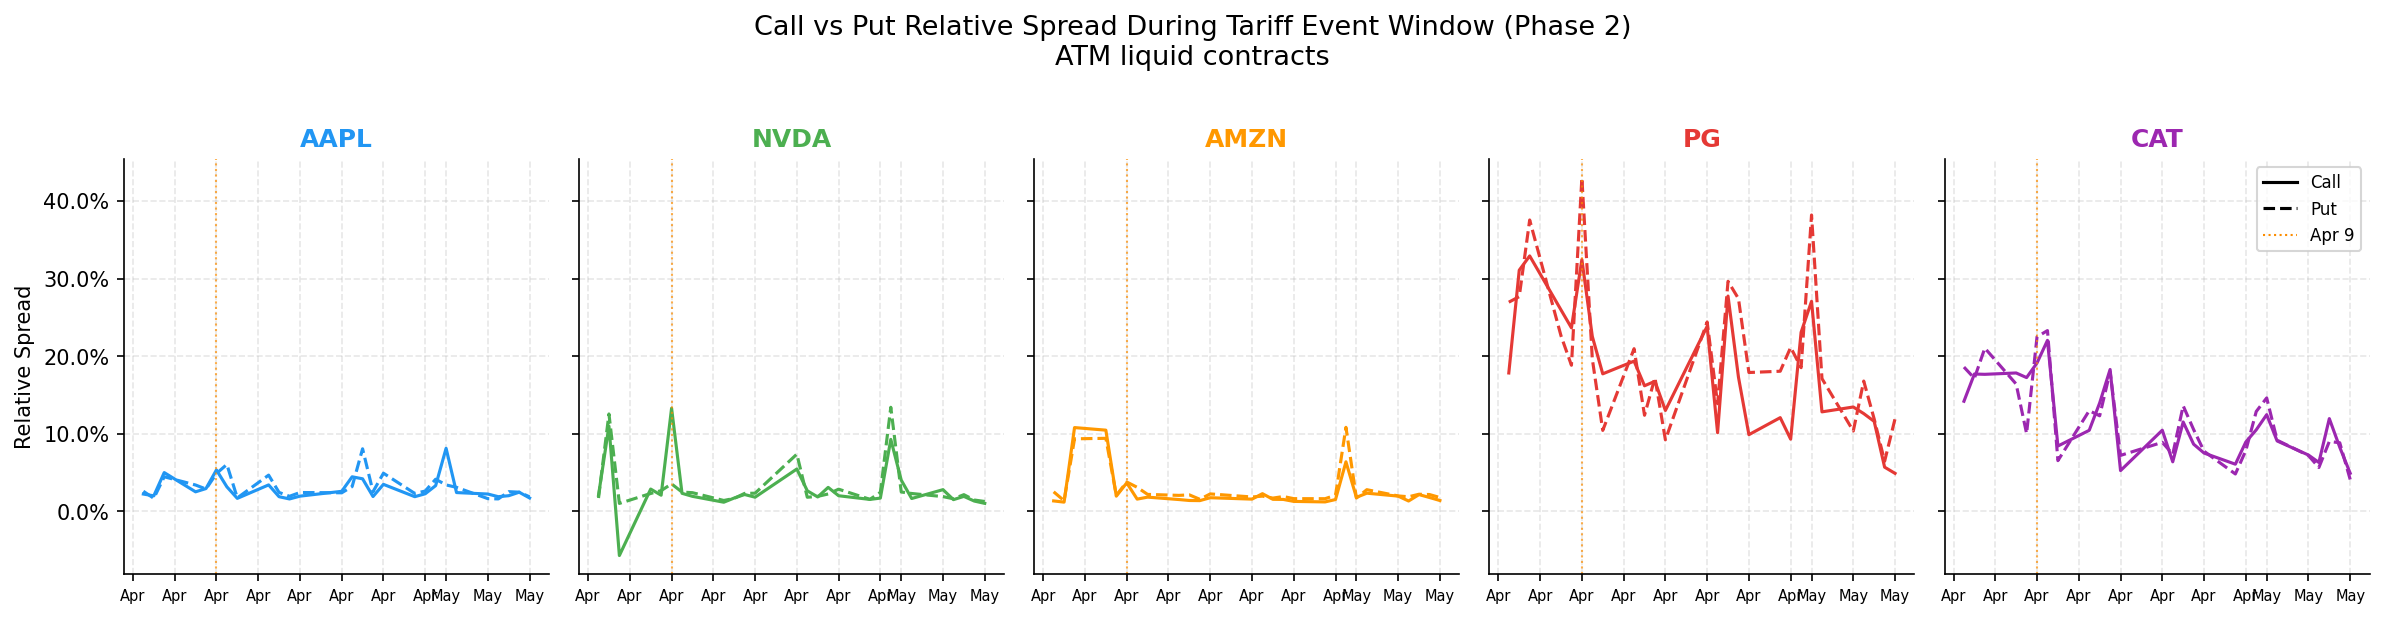

In [31]:
print("Generating Figure 7: call vs put spread...")

phase2 = cross[cross["phase"] == 2].copy()
cp_ts = (
    phase2.groupby(["collection_date", "ticker", "side"])["relative_spread"]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax, ticker in zip(axes, TICKERS):
    data = cp_ts[cp_ts["ticker"] == ticker]
    for side, ls, label in [("call", "-", "Call"), ("put", "--", "Put")]:
        sdata = data[data["side"] == side]
        ax.plot(sdata["collection_date"], sdata["relative_spread"],
                color=COLORS[ticker], linestyle=ls, linewidth=1.5, label=label)

    ax.axvline(pd.Timestamp("2025-04-09"), color=EVENT_COLORS[1],
               linestyle=":", linewidth=1, alpha=0.7)
    ax.set_title(ticker, color=COLORS[ticker], fontweight="bold", fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", labelsize=7)
    if ax == axes[0]:
        ax.set_ylabel("Relative Spread")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="black", linestyle="-",  linewidth=1.5, label="Call"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Put"),
    Line2D([0], [0], color=EVENT_COLORS[1], linestyle=":", linewidth=1, label="Apr 9"),
]
axes[-1].legend(handles=legend_handles, fontsize=8, loc="upper right")

fig.suptitle("Call vs Put Relative Spread During Tariff Event Window (Phase 2)\n"
             "ATM liquid contracts", fontsize=13, y=1.02)
fig.tight_layout()

# save(fig, "fig7_call_put_spread.png")
plt.show()

## Figure 8: Recovery, Phase 3 vs Phase 1

We measure how each sector recovered pre and post shock event through the use of a recovery ratio:
$$\text{recovery ratio} = \frac{\text{Phase 3 spread}}{\text{Phase 1 baseline spread}}$$

Interpretation of results:
- **= 1.0** — fully recovered
- **> 1.0** — still wider than pre-tariff
- **< 1.0** — tighter than baseline (overshooting recovery)

Observation from figure:
- Large fluctuations across all sectors
- By Jan 2026, most sectors have recovered, PG has the largest recovery ratio, signalling that it has not recovered fully. AAPL and NVDA have overshot and are outperforming their phase 1 baseline

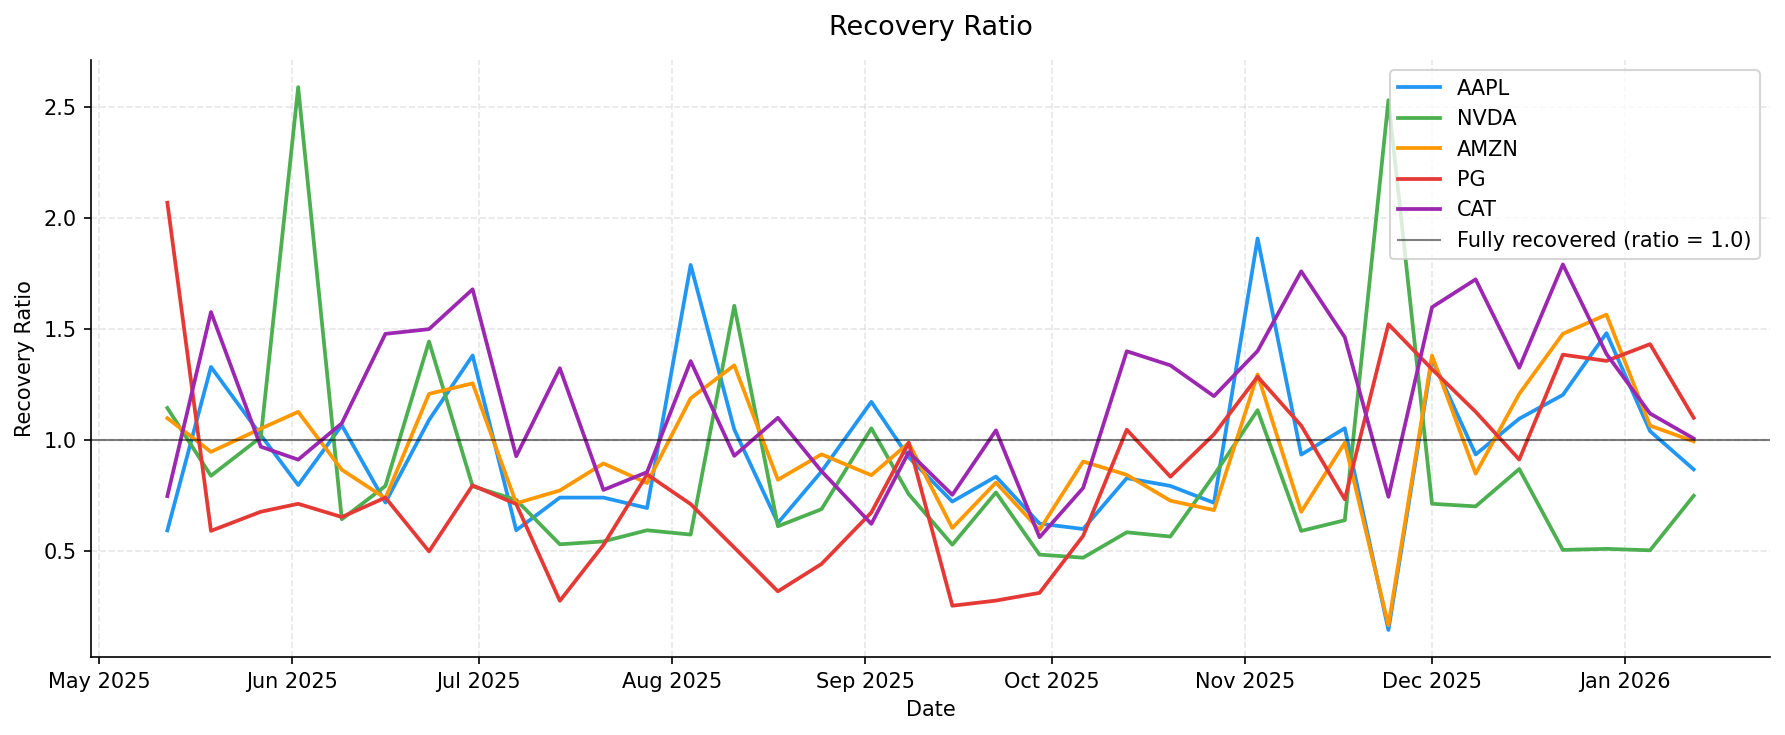

In [33]:
# Baseline: median ATM relative spread per ticker in Phase 1
baseline = (
    cross[cross["phase"] == 1]
    .groupby("ticker")["relative_spread"]
    .median()
    .rename("baseline")
)

# Phase 3: median ATM relative spread per collection date per ticker
phase3_ts = (
    cross[cross["phase"] == 3]
    .groupby(["collection_date", "ticker"])["relative_spread"]
    .median()
    .reset_index()
)
phase3_ts = phase3_ts.join(baseline, on="ticker")
phase3_ts["recovery_ratio"] = phase3_ts["relative_spread"] / phase3_ts["baseline"]

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    data = phase3_ts[phase3_ts["ticker"] == ticker]
    ax.plot(data["collection_date"], data["recovery_ratio"],
            color=COLORS[ticker], label=ticker, linewidth=1.8)

ax.axhline(1.0, color="black", linestyle="-", linewidth=1.0,
           alpha=0.5, label="Fully recovered (ratio = 1.0)")

ax.set_title("Recovery Ratio",
             fontsize=13, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Recovery Ratio")
ax.legend(loc="upper right", framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()

# save(fig, "fig8_recovery.png")
plt.show()